# 시작하기

In [ ]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# shap: 모델에 대한 변수들의 영향을 볼 수 있도록. (feature importance 간단히 시각화)
# 앙상블 -> 트리계열에서 많이 사용 (XGBoost, LightGBM, CatBoost)
# 노드별 접근, 스케일링 필요성 적음
import shap

In [ ]:
#drive mount
from google.colab import drive
drive.mount('/content/drive', force_remount= True)
origin = ('/content/drive/MyDrive/새싹과정/my/4주차/모의 대회용 데이터 (병원 개 폐업)')


test_df = pd.read_csv(os.path.join(origin, 'test.csv'))
train_df = pd.read_csv(os.path.join(origin, 'train.csv'))
sample = pd.read_csv(os.path.join(origin, 'submission_sample.csv'))

Mounted at /content/drive


# 1. 데이터 전처리

- 데이터 이슈:
    - train - test 차이: train 에 있는 내용이 test에는 없어 라벨 인코딩이 어려웠음.
    - -> train + test 합쳐서 전처리
- 둘다 동일한 열을 가지니,, 행을 합쳐 1 df로 만드는 방법
- -> train / test 구분을 위해 type 열(train / test)을 임의로 추가.
- 동일하게 전처리, 인코딩 진행 후 머신러닝 전에 분리


In [ ]:
#내용으로 들어갈 'train'으로 채워진 리스트
#방법1 for문으로 만들기
train_type = []

for i in range(len(train_df)):
    train_type.append('train')

print(f'리스트의 길이 {len(train_type)}, 리스트 출력 {(train_type)}')

리스트의 길이 301, 리스트 출력 ['train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train', 'train'

In [ ]:
#train 과 test 합치기 위해 'type'이라는 이름의 열 추가
train_df['type'] = train_type

#방법2 리스트 컴프리헨션으로 만들기
test_df['type'] = ['test' for x in range(len(test_df))]

In [ ]:
#train + test 합치기
#axis = 1: 열방향, 세로방향으로 붙음
#=0: 행방향, 가로방향으로 붙음
total_df = pd.concat([train_df, test_df])
total_df

,inst_id,OC,sido,sgg,openDate,bedCount,instkind,revenue1,salescost1,sga1,...,liquidLiabilities2,shortLoan2,NCLiabilities2,longLoan2,netAsset2,surplus2,employee1,employee2,ownerChange,type
0,1,open,choongnam,73,20071228.0,175.0,nursing_hospital,4.217530e+09,0.000000e+00,3.961135e+09,...,2.228769e+08,0.000000e+00,5.361169e+08,3.900000e+08,2.619290e+09,1.271224e+09,62.0,64.0,same,train
1,3,open,gyeongnam,32,19970401.0,410.0,general_hospital,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,801.0,813.0,same,train
2,4,open,gyeonggi,89,20161228.0,468.0,nursing_hospital,1.004522e+09,5.154837e+08,4.472197e+08,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,234.0,1.0,same,train
3,7,open,incheon,141,20000814.0,353.0,general_hospital,7.250734e+10,0.000000e+00,7.067740e+10,...,1.701860e+10,9.219427e+09,2.073641e+10,1.510000e+10,1.295427e+10,7.740829e+09,663.0,663.0,same,train
4,9,open,gyeongnam,32,20050901.0,196.0,general_hospital,4.904354e+10,0.000000e+00,4.765605e+10,...,3.007259e+10,1.759375e+10,2.136001e+10,1.410803e+10,5.561941e+06,9.025550e+09,206.0,197.0,same,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,424,NaN,jeonnam,33,20011012.0,0.0,traditional_clinic,2.233031e+10,8.484657e+08,1.849255e+10,...,1.288180e+10,0.000000e+00,2.750371e+09,0.000000e+00,1.384958e+10,0.000000e+00,560,NaN,NaN,test
123,425,NaN,gyeonggi,74,20010530.0,NaN,traditional_hospital,1.833906e+10,0.000000e+00,1.760117e+10,...,1.376742e+09,0.000000e+00,1.799886e+09,1.740000e+09,8.574502e+09,7.136681e+09,132,137,same,test
124,429,NaN,gyeonggi,116,20010101.0,150.0,hospital,1.424266e+10,1.726174e+09,1.148722e+10,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,test
125,430,NaN,jeju,76,20010201.0,NaN,NaN,4.892710e+10,4.157148e+10,4.721485e+09,...,8.485918e+09,0.000000e+00,2.871805e+10,2.563120e+10,-2.050629e+08,0.000000e+00,363,343,same,test


In [ ]:
source = total_df.copy()

#원본데이터 보존용, 전처리는 total_df로 처리

## - 1. 전처리
- OC 전처리
- employee1, 2 전처리 (데이터 클리닝, 영향이 있는 전처리는 아님)

In [ ]:
#strip 방법도 있음 (생각 안 났다 ㅎ)
total_df['OC'].replace({'open': 1, 'close': 0, ' close': 0}, inplace = True)
total_df['OC'].isnull().sum()
# 결과 해석
#np.int64(127): test에는 답이 없음. test에는  'OC'가 원래 없기에 정상

/tmp/ipykernel_6285/4199382525.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  total_df['OC'].replace({'open': 1, 'close': 0, ' close': 0}, inplace = True)
/tmp/ipykernel_6285/4199382525.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  total_df['OC'].replace({'open': 1, 'close': 0, ' close': 

np.int64(127)

In [ ]:
for col in ['employee1', 'employee2']:
    total_df[col] = total_df[col].astype(str).replace(',', '')
    total_df[col] = total_df[col].replace('-', '')
    # string -> 수치화, errors = 'coerce'(결측치 강제로 nan 설정하는 것)
    total_df[col] = pd.to_numeric(total_df[col], errors = 'coerce')

In [ ]:
total_df['employee1'].unique()      # 에러 없이 잘 변형 되었는가 확인

array([6.20e+01, 8.01e+02, 2.34e+02, 6.63e+02, 2.06e+02, 3.97e+02,
       2.21e+02, 4.89e+02, 2.43e+02, 3.70e+02, 5.30e+01, 2.97e+02,
       5.40e+01, 2.09e+02, 9.51e+02, 1.83e+02, 4.09e+02, 4.20e+01,
       1.94e+02, 3.55e+02, 6.06e+02, 1.17e+02, 1.64e+02, 2.66e+02,
       1.56e+02, 1.48e+02, 4.18e+02, 2.49e+02, 9.30e+01, 9.40e+01,
       3.23e+02, 9.60e+01, 5.10e+01, 1.37e+02, 9.00e+01, 9.90e+01,
       4.54e+02, 2.05e+02, 2.10e+02, 1.31e+02, 1.27e+02, 1.20e+02,
       2.95e+02, 8.60e+01, 1.32e+02,      nan, 3.00e+02, 7.30e+01,
       1.19e+02, 7.40e+01, 2.65e+02, 2.01e+02, 2.00e+02, 1.62e+02,
       7.50e+01, 1.08e+02, 2.70e+02, 3.80e+01, 4.40e+01, 7.20e+01,
       1.29e+02, 6.70e+01, 5.07e+02, 4.00e+01, 1.92e+02, 8.50e+01,
       8.10e+01, 1.07e+02, 3.50e+01, 2.22e+02, 7.90e+01, 7.80e+01,
       2.55e+02, 7.10e+01, 4.10e+01, 1.65e+02, 8.00e+01, 6.40e+01,
       5.00e+01, 6.00e+01, 1.26e+02, 2.70e+01, 8.30e+01, 4.60e+01,
       4.06e+02, 5.20e+01, 7.70e+01, 2.35e+02, 4.00e+00, 1.52e

# 2. 파생변수 만들기 or X 변수 정리하기


- opendate : '최신 날짜' 대비 days로 변환 (얼마나 오래 운영했는지)
- 상관관계 시각화
- shap 사용, feature importance 확인 -> X 중에 뭘 남길지 확인 가능
- 사용할 X만 분리

In [ ]:
total_df['openDate'] = pd.to_datetime(source['openDate'])
total_df['openDate'].unique()

<DatetimeArray>
['2007-12-28 00:00:00', '1997-04-01 00:00:00', '2016-12-28 00:00:00',
 '2000-08-14 00:00:00', '2005-09-01 00:00:00', '2002-05-01 00:00:00',
 '1982-07-02 00:00:00', '1987-11-02 00:00:00', '2006-09-22 00:00:00',
 '2000-01-24 00:00:00',
 ...
 '2013-12-26 00:00:00', '2011-09-26 00:00:00', '1993-06-14 00:00:00',
 '1970-01-01 00:00:00', '2011-04-15 00:00:00', '2001-10-12 00:00:00',
 '2001-05-30 00:00:00', '2001-01-01 00:00:00', '2001-02-01 00:00:00',
 '1996-12-16 00:00:00']
Length: 405, dtype: datetime64[ns]

In [ ]:
#opendate 날짜 형태로 변환,(위에서 진행 되었으니 패스datetimearray)
# total_df['openDate'] = total_df['openDate'].fillna(0).astype(int).astype

# total_df['openDate'].dtypes

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Timestamp'

In [ ]:
total_df['openDate'] = pd.to_datetime(total_df ['openDate'], format ='%Y%m%d', errors = 'coerce')

#1차오류: pd.to_datetime(total_df ['openDate']) 까지만
#1970-01-01 00:00:00.020071228 -> float을 변환하게 되면 70년 기준으로 설정이 된 것.
#우선 정수화, 문자열화 단계를 거쳐야함

 #2차 오류: time data "-9223372036854775808" doesn't match format "%Y%m%d"
 # "-9223372036854775808"이 일괄적으로 변환되는 단계~
 # format ='%Y%M%D', errors = 'coerce'으로 설정

In [ ]:
#latest_day: = 기준 날짜 이 열에서 가장 최신 날짜를 얻기 = 기준 날짜
latest_day = total_df['openDate'].max()
print(latest_day)

#개업일과 기준 날짜의 차이를 얻을 수 있음
#.dt.days: ~days 삭제
total_df['open_days'] = (latest_day - total_df['openDate']).dt.days
total_df['open_days']

2017-06-07 00:00:00


,open_days
0,3449
1,7372
2,161
3,6141
4,4297
...,...
122,5717
123,5852
124,6001
125,5970


# 2-2. 상관계수 확인


- 다중공산성:X끼리 관계가 깊어 Y 예측에 안 좋은 영향을 주는 것
- 이를 위해서 X끼리 상관관계 확인
 -> 따로 떼어 차원축소하는 식으로 진행하기도 함

- 상관계수: -1~1 (강한, 약한 상관관계 수치 기억해내삼)

 -> 이전까지는 머신러닝 들어가기 전 모두 인코딩 된 열을 한꺼번에 상관계수 확인하는 방법이었음
- 통계에서는 숫자 데이터 / 인코딩 데이터 따로 분리한뒤 진행하는 것이 좋음

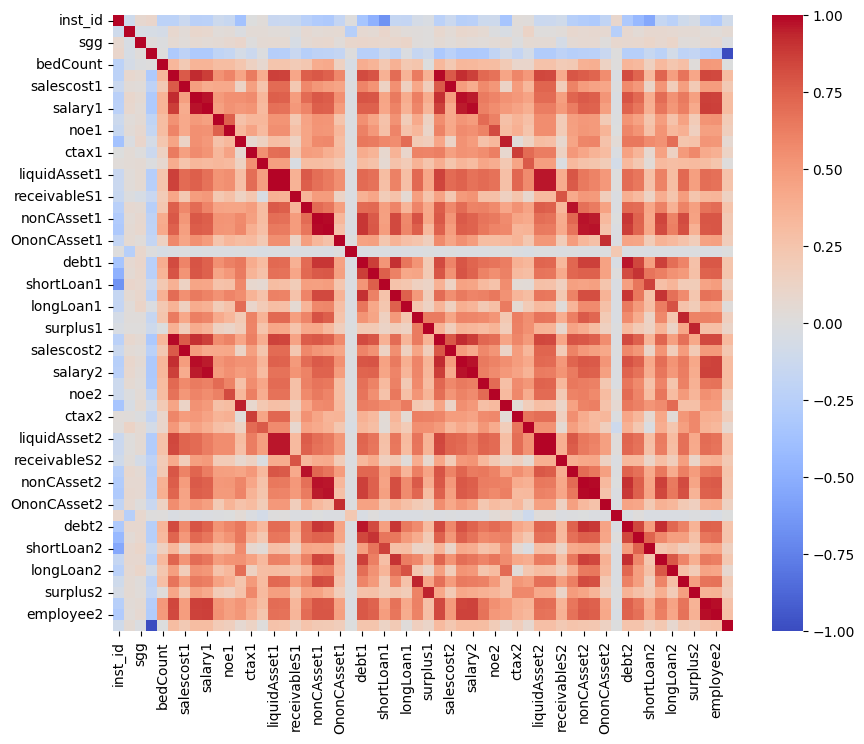

In [ ]:
#1. 숫자로 된 데이터들 사이의 상관관계 확인
#-1. 숫자 컬럼 선별
target_col = [x for x in total_df.columns if total_df[x].dtypes != 'object']

# target_col = []
# for i in total_df.columns:
    #if total_df[i].dtypes != 'object':
        #target_col.append(i)


#-2. 상관계수 행렬 만들기
#target_col: 숫자로 된 열 이름만 모아둔 리스트
#total_df[target_col]: total_df에서 [target_col]만 가져와 주시요
#cov: 상관 분산. (x들 사이 분산)
numeric_corr = total_df[target_col].corr()



#-3. 행렬 시각화
plt.figure(figsize = (10,8))
sns.heatmap(numeric_corr, annot=False, cmap = 'coolwarm')
plt.show()

In [ ]:
# 행렬 시각화에서 원하는 값(강한 상관관계 보이는 컬럼들) 분리해오기
threshold = 0.7         # 강한 상관관계 추출 기준점  (임계값)

#절댓값 기준 강한 상관관계 추출 위해 변형
numeric_corr = total_df[target_col].corr().abs()


#아래쪽 삼각형만 추출 + 관련성 있는 x를 '임계값' 기준으로 적용

#np.triu(np.ones(numeric_corr.shape), k=1): 넘파이함수, 삼각형, upper. (상관관계의 대각선 생각해보면)
#np.ones():어떠한 행렬을 줄테니 이만큼 1로 채우세요
#numeric_corr.shape: 상관 행렬화
#k=1: 옵션. 대각선은?> 포함하여 0으로 한다는 뜻
#where: numeric_corr에서 어디를 바꿀 것인지 지정
np.triu(np.ones(numeric_corr.shape), k=1)
drop_col = numeric_corr.where(np.triu(np.ones(numeric_corr.shape), k=1).astype(bool))            # ValueError: Boolean array expected for the condition, not float64 -> astype으로 bool 설정 해결

#기준점을 갖고, 기준 초과인 컬럼 탐색(다중공산성)
#any: 한 개라도 해당이 된다면
drops = [col for col in drop_col.columns if (drop_col[col]>threshold).any()]

In [ ]:
# 보충 설명: 각 행별로 임계값보다 높은지를 보고
drop_col['bedCount']>threshold
#위에 any를 추가하면 아래의 계산 결과에서 하나라도 true가 있다면 true 값만 추출하여 나옴
#이러한 것들을 'bedCount'뿐만 아니라 drop_cal의 컬럼들을 순회하며 실행. true 값 나온 것들은 drops에 저장

,bedCount
inst_id,False
OC,False
sgg,False
openDate,False
bedCount,False
revenue1,False
salescost1,False
sga1,False
salary1,False
noi1,False


In [ ]:
(drop_col['bedCount']>threshold).any()

np.False_

In [ ]:
#drops: 상관관계가 0.7 이상 값 이 있는 열 이름의 리스트
#target_col: 숫자로 된 열의 이름 리스트
#total_df.columns: 전체 열의 이름 리스트
len(drops), len(target_col), len(total_df.columns)
#결과해석
#(41, 56, 60) -> 41개는 다중공산성에 해당되는 것들

(41, 56, 60)

In [ ]:
#2. 문자열 데이터 상관관계
# -> 상관계수 2가지: 피어슨(숫자), 스피어만(~숫자. 순위. 적어도 인코딩 가능)
#corr(method에 기본적으로 스피어만이 설정되어 있음)
#여기서는 스피어만 방식이 그렇게 좋은 방법은 아니라 크래머V 이용해서 상관관계 그려볼 것임

#숫자가 아닌 열들의 상관계수 확인
#scipy : 수학적 계산, 공식 작성 보조 라이브러리
import numpy as np
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    """ 두 범주형 변수 간의 크래머 V 계수를 계산하는 함수 """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # 편향 보정(Bias correction) 적용
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


In [ ]:
#total_df에서 열의 데이터가 '문자'인 것만 모음
category_col = [x for x in total_df.columns if total_df[x].dtypes == 'object']

#['sido', 'instkind', 'ownerChange', 'type'] -> 4행, 4열로
#np.ones랑 유사 np.ones(zeros)(행렬크기)
cramer = pd.DataFrame(np.zeros((len(category_col), len(category_col))))

In [ ]:
category_col

['sido', 'instkind', 'ownerChange', 'type']

In [ ]:
#위에서 만든 함수를 모든 행과 열에 대해 계산
for i in range(len(category_col)):
    for j in range(len(category_col)):
        x = total_df[category_col[i]]
        y = total_df[category_col[j]]
        cramer.iloc[i,j] = cramers_v(x, y)          #x, y는 위치


# i= 0,j= 0,1,2,3 돌고 i = 1, j = 0,1,2,3 도는 방식

In [ ]:
cramer

,0,1,2,3
0,1.000000,0.112084,0.193089,0.139323
1,0.112084,1.000000,0.000000,0.000000
2,0.193089,0.000000,0.989102,0.020968
3,0.139323,0.000000,0.020968,0.994389


<Axes: >

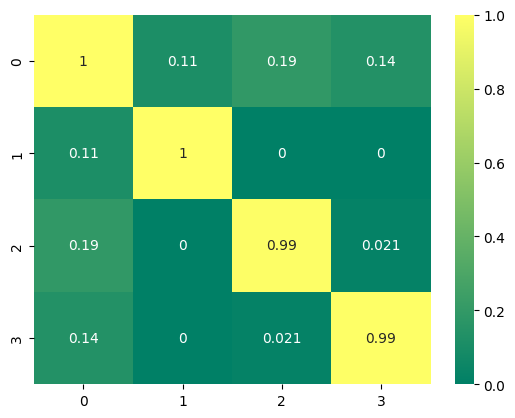

In [ ]:
sns.heatmap(cramer,cmap = 'summer', annot = True)

# SHAP 피쳐 임포턴스 추출

In [ ]:
# 3. shap
!pip install shap

In [ ]:
import shap
from lightgbm import LGBMClassifier

In [ ]:
y = temp['OC']
x = temp.drop(columns=['OC','inst_id', 'type', 'openDate' ])

In [ ]:
#0. 1을 위해서 인코딩을 한다. x, y데이터를 만든다.
#train, test => total_df
#total_df로 X, y를 만들자. => train, test를 분리 => train만 추출, x,y로 다시 추출
temp = total_df[total_df['type'] == 'train']
temp.head()

# y = temp['OC']
# x = temp.drop(columns=['OC','inst_id', 'type', 'openDate' ])

#문자열 인코딩
from sklearn.preprocessing import LabelEncoder
for c in x.columns:
    if x[c].dtypes == 'object':
        LE = LabelEncoder()
        x[c] = LE.fit_transform(x[c])

#결측치가 많지는 않아서 임시로 shap 돌리기 위해 결측치 대체 진행 (원래라면 결측치 분석이 필요)
x.fillna(0, inplace=True)

#1. 머신러닝을 LGBM으로 돌려본다.
model = LGBMClassifier().fit(x,y)



[LightGBM] [Info] Number of positive: 286, number of negative: 15
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4084
[LightGBM] [Info] Number of data points in the train set: 301, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.950166 -> initscore=2.947942
[LightGBM] [Info] Start training from score 2.947942
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

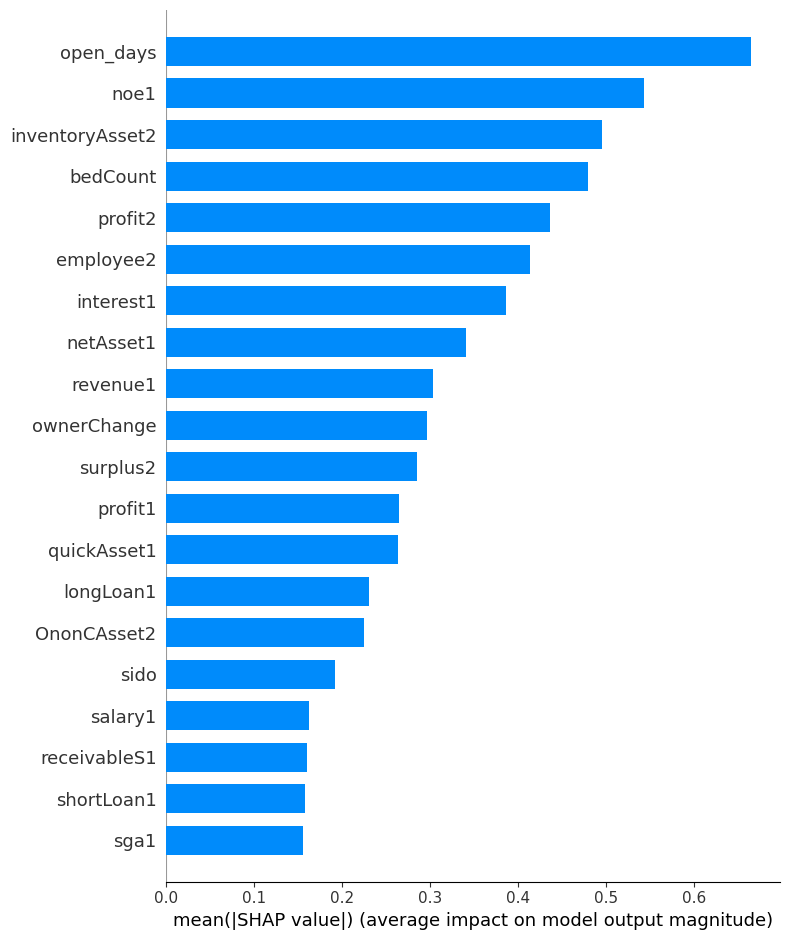

In [ ]:
#2. 1을 바탕으로 shap분석을 한다.
#shap.TreeExplainer에 내가 훈련시킨 'model'을 주고
explainer = shap.TreeExplainer(model)

#3. 주요 feature를 추출한다.
#explainer:내가 갖고 있는 x
shape_vales = explainer(x)
shap.summary_plot(shape_vales, x, plot_type = 'bar')

#결과해석: 영향이 큰 것 순으로 도출됨
# 갈림길: 상위 몇개 뽑아서 머신러닝 다시 돌려볼 수 있고 / drops와 함께 비교하며 제거여부 결정하기

# 모델은 교체하며 검증해볼것

In [ ]:
x.isnull().sum()

,0
sido,0
sgg,0
bedCount,5
instkind,0
revenue1,8
salescost1,8
sga1,8
salary1,8
noi1,8
noe1,8


#3. 훈련하기

- 상위 n개의 feature 갖고 훈련 시키기

- 결측치 올바르게 메꾸는 방법 < - 인코딩 + 결측치
    - => 이상치가 많은 데이터여서 중앙값으로 메꾸는 것이 최선
- 밸런스 맞추기

In [ ]:
#결측치 대체
#1.단순 대치 (결측치 제거)
#2. 조건부 대치(회귀식 찾아 대체)
#3. 비조건부 대치 (평균, 중앙값...) -> 현 스텝에서 가장 많이 사용 가능
#평균값 대치, 중앙값 대치 구분 기준: box plot으로 시각화 하여 판단
#분포도의 왜도가 0에서 벗어난 경우를 생각
#중앙값 사용: 이상치가 많은 경우

#결측치가 하나 이상 있는 열 -> nans라는 리스트에 추가
nans = [x for x in total_df.columns if total_df[x].isnull().sum() > 0]
nans.remove('OC')

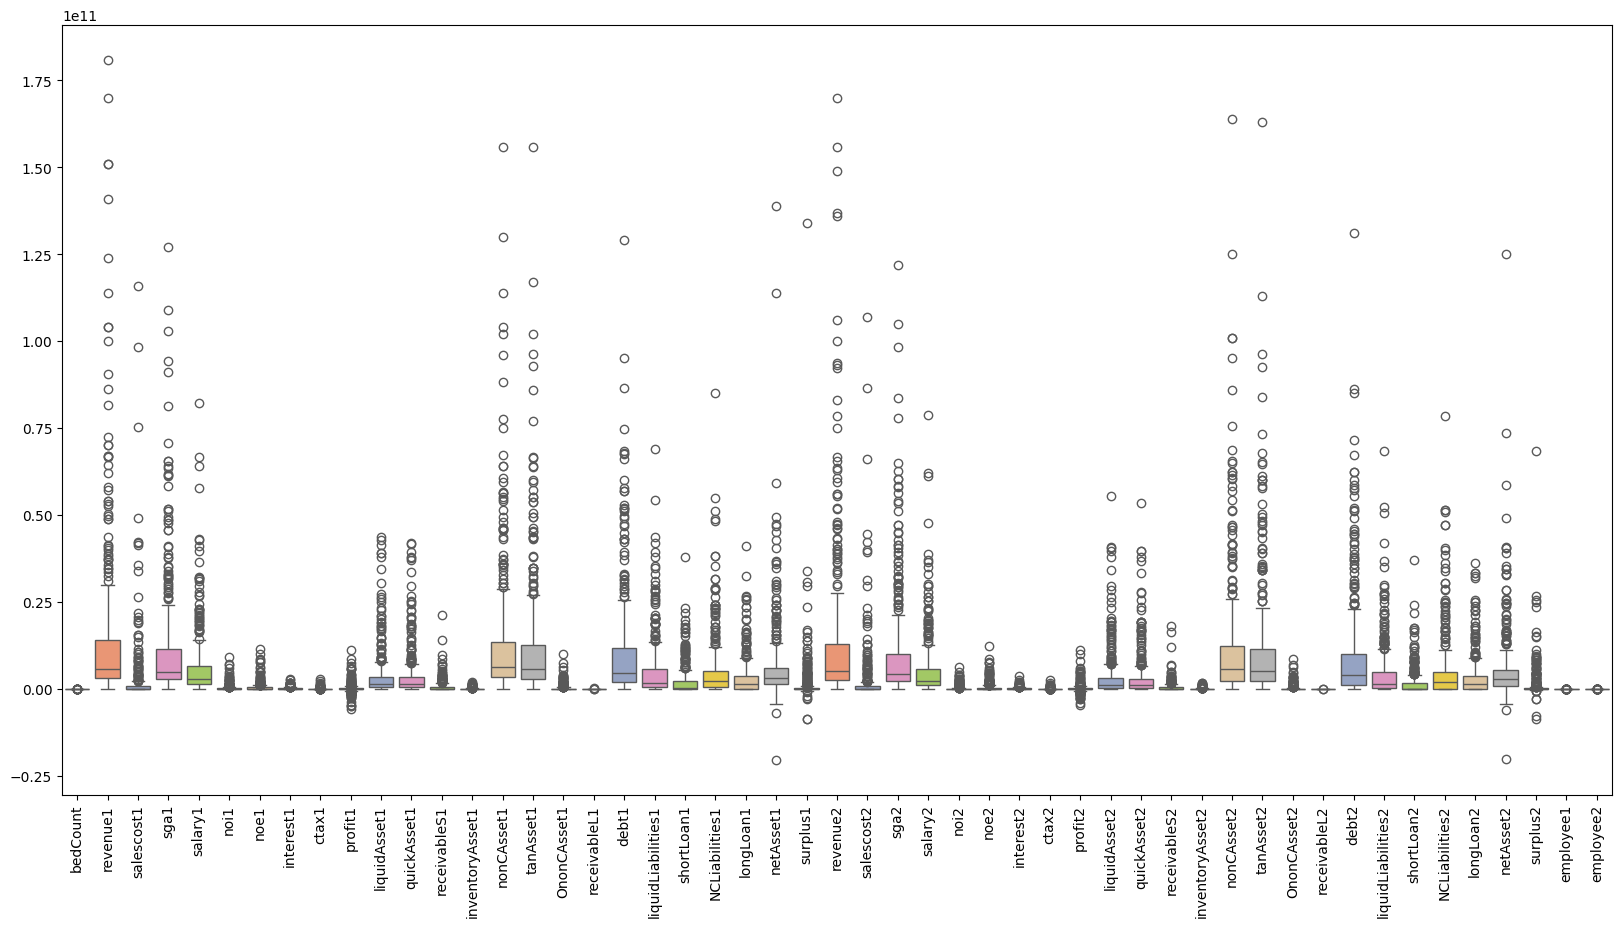

In [ ]:
#nans라는 '결측치 값이 있는 리스트'에 대해 그림을 그림
plt.figure(figsize = (20,10))
sns.boxplot(data = total_df[nans], palette = 'Set2')
plt.xticks(rotation = 90)
plt.show()

In [71]:
#인코딩
from sklearn.preprocessing import OrdinalEncoder

#unknown 옵션 없이 진행 가능(total_df로 합친 이유가 이것)
#전체 데이터가 있는 상황에서 인코딩 => 예외 값 발생 X, 한꺼번에 해서 편리함

for col in total_df.columns:
    if total_df[col].dtypes == 'object':
        oe = OrdinalEncoder()
        total_df[col] = oe.fit_transform(total_df[[col]])

In [72]:
#중앙값 대치 코드
#결측치가 있는 모든 열에 대해 그 열의 중앙값 계산 -> fillna()

for i in nans:
    value = total_df[i].median()
    total_df[i].fillna(value, inplace = True)

/tmp/ipykernel_6285/935601550.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  total_df[i].fillna(value, inplace = True)


## 머신러닝 모델에 넣기 위해 쪼개기

- train / test

In [73]:
total_df.isnull().sum()

,0
inst_id,0
OC,127
sido,0
sgg,0
openDate,0
bedCount,0
instkind,0
revenue1,0
salescost1,0
sga1,0


In [75]:
total_df['type'].value_counts()

#1 :
#0 : test

,count
type,
1.0,301
0.0,127


In [76]:
real_train = total_df[ total_df['type']==1]
real_test = total_df[ total_df['type']==0]
print(len(real_train), len(real_test))

301 127


In [80]:
real_train_y = real_train['OC']
real_train_x = real_train.drop(columns = ['OC','openDate','type'])

In [81]:
real_train_x.head()

,inst_id,sido,sgg,bedCount,instkind,revenue1,salescost1,sga1,salary1,noi1,...,liquidLiabilities2,shortLoan2,NCLiabilities2,longLoan2,netAsset2,surplus2,employee1,employee2,ownerChange,open_days
0,1,2.0,73,175.0,4.0,4.217530e+09,0.0,3.961135e+09,2.033835e+09,15652441.0,...,2.228769e+08,0.000000e+00,5.361169e+08,3.900000e+08,2.619290e+09,1.271224e+09,62.0,64.0,1.0,3449
1,3,9.0,32,410.0,2.0,5.801359e+09,205549069.0,5.047266e+09,2.810168e+09,47478701.0,...,1.454651e+09,1.189736e+08,1.976311e+09,1.426160e+09,2.808020e+09,0.000000e+00,801.0,813.0,1.0,7372
2,4,8.0,89,468.0,4.0,1.004522e+09,515483669.0,4.472197e+08,2.964023e+08,76156.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,234.0,1.0,1.0,161
3,7,10.0,141,353.0,2.0,7.250734e+10,0.0,7.067740e+10,3.178605e+10,506223059.0,...,1.701860e+10,9.219427e+09,2.073641e+10,1.510000e+10,1.295427e+10,7.740829e+09,663.0,663.0,1.0,6141
4,9,9.0,32,196.0,2.0,4.904354e+10,0.0,4.765605e+10,2.446078e+10,112352259.0,...,3.007259e+10,1.759375e+10,2.136001e+10,1.410803e+10,5.561941e+06,9.025550e+09,206.0,197.0,1.0,4297


# 훈련 준비 끝
- real_train_y, real_train_x 가 학습용 자료

In [82]:
#모델 학습
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.1,max_depth =3)
xgb.fit(real_train_x, real_train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [83]:
real_test_x = real_test.drop(columns = ['OC','openDate','type'])
xgb_predict = xgb.predict(real_test_x)
print(xgb_predict)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1]


In [85]:
# sample의 OC열에 위의 예측값을 넣음 끝

sample['OC'] = xgb_predict
sample.to_csv('/content/xgb_submit.csv', index = False)

## SMOTE

- 라벨의 밸런스가 붕괴된 상황에 사용
- open과 close 비율이 붕괴되었음.

In [87]:
#데이터 편향성 우려
#SMOTE -> 부족한 데이터를 증강시켜 개수를 비슷하게 생성해줌.
# 0이라는 라벨의 X데이터를 '가상으로 생성' until 내가 정해놓은 비율 달성


#오버샘플링: 부족한 데이터를 중복해서 추출해 개수 맞춰줌
#언더샘플링: 많은 쪽 데이터를 더 적게 뽑아 개수(비율) 맞춰줌
real_train_y.value_counts()

,count
OC,
1.0,286
0.0,15


In [88]:
from imblearn.over_sampling import SMOTE

#resample 전략은 데이터 특성에 따라 판단할 것
#sampling_strategy: 비율 맞춰주기
smote = SMOTE(sampling_strategy = 'auto', random_state = 42)
x_train_over, y_train_over = smote.fit_resample(real_train_x, real_train_y)

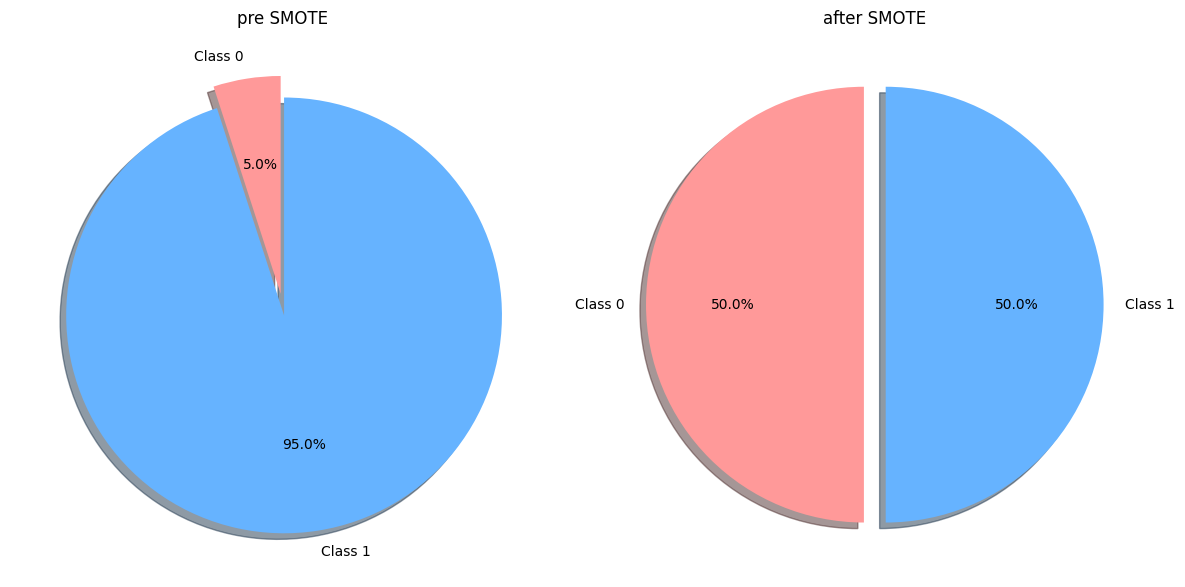

In [89]:
# 1. 서브플롯 생성 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


# 데이터 라벨 정의 (예: 0=정상, 1=사기)
labels = ['Class 0', 'Class 1']
colors = ['#ff9999', '#66b3ff'] # 부드러운 파스텔톤 컬러
explode = (0.05, 0.05)          # 조각 떼어내기 효과


# 2. SMOTE 적용 전 파이 차트 (왼쪽)
before_counts = pd.Series(real_train_y).value_counts().sort_index()
axes[0].pie(before_counts, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90)
axes[0].set_title('pre SMOTE')


# 3. SMOTE 적용 후 파이 차트 (오른쪽)
after_counts = pd.Series(y_train_over).value_counts().sort_index()
axes[1].pie(after_counts, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90)
axes[1].set_title('after SMOTE')


plt.tight_layout()
plt.show()
